In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import glob
import astropy.io.fits as fits
# Put in the pyodine path on your machine here!
pyodine_path = '/home/skleiman/pyodineAPF'

sys.path.append(pyodine_path)

import pyodine
import pyodine_create_templates     # <- the template creation routines
import utilities_apf as utilities


In [2]:
Pars = utilities.pyodine_parameters.Template_Parameters()
Pars.deconvolution_pars

{'osample_temp': 10,
 'jansson_niter': 1200,
 'jansson_zerolevel': 0.0,
 'jansson_contlevel': 1.02,
 'jansson_conver': 0.2,
 'jansson_chi_change': 1e-06,
 'lsf_conv_width': 6.0}

In [3]:
#10 01 for O star, HR files

# O-star observations to use for the mod?elling
ostar_dir   = "/data/APF_reductions/HD203030/20241001/PyPyPiOUT/"
#ostar_files = glob.glob(ostar_dir+"PyPyPied_In_HR7906*")
#ostar_files2 = glob.glob(ostar_dir+"PyPyPied_In_HR8781*")
ostar_files = glob.glob(ostar_dir+"PyPyPied_In_*")
#for name in ostar_files2:
#   ostar_files.append(name)
#ostar_files = ostar_files[0:2]
print(ostar_files)

# HD 203030 files
# Stellar observations to use for the deconvolution
temp_dir   = "/data/APF_reductions/HD203030/20241001/PyPyPiOUT/"
temp_files =  glob.glob(ostar_dir+"PyPyPied_Out_HD*")
temp_files.sort()
print(temp_files)

# Output pathname for the summed, normalized template observations
obs_sum_outname = os.path.join("/data/APF_recuctions/HD203030/20241001/summed_HD203030.fits")

# Output pathname for the template
temp_outname = os.path.join("/data/APF_recuctions/HD203030/20241001/template_HD203030.fits")

# Output directory for plots and pathnames for modelling results
os.makedirs("/data/APF_recuctions/HD203030/20241001/pyodine_outs/", exist_ok=True)
plot_dir  = "/data/APF_recuctions/HD203030/20241001/pyodine_outs/"
res_files = [os.path.join(plot_dir, 'HD203030_2024_10_01_res0.h5'),
             os.path.join(plot_dir, 'HD203030_2024_10_01_res1.pkl')]

# Log files
error_file = os.path.join(plot_dir, 'error.log')
info_file  = os.path.join(plot_dir, 'info.log')

['/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7528_20241001_13691.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7906_20241001_13707.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7906_20241001_13706.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR8781_20241001_13715.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7528_20241001_13692.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR8781_20241001_13716.fits']
['/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13708.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13709.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13710.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13711.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_2024


Branch: main
Hash: 2060894
---------------------------
Aiming to create template: /data/APF_recuctions/HD203030/20241001/template_HD203030.fits
APF IN USE
APF IN USE
APF IN USE
APF IN USE
APF IN USE
APF IN USE

Hot star observations (6):
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7528_20241001_13691.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7906_20241001_13707.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7906_20241001_13706.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR8781_20241001_13715.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7528_20241001_13692.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR8781_20241001_13716.fits
APF IN USE
APF IN USE
APF IN USE
APF IN USE
APF IN USE
APF IN USE
APF IN USE

Stellar template observations (7):
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13708.fits
/data/APF_reductions/HD203030


----------------------
RUN 0
----------------------
<class 'pyodine.models.cont.LinearContinuumModel'>
> /home/skleiman/pyodineAPF/pyodine_create_templates.py(361)create_template()
    359             # If the LSF model is a fixed LSF, try and smooth LSF results from
    360             # an earlier run
--> 361             if lsf_model.name() == 'FixedLSF':
    362                 if 'smooth_lsf_run' not in run_dict.keys():
    363                     smooth_lsf_run = run_id - 1

MODEL DIRECTORY
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'all_param_names', 'clean_of_I2', 'cont_model', 'conv_width', 'eval', 'eval_lsf', 'eval_spectrum', 'guess_params', 'iodine_atlas', 'lsf_a

/home/skleiman/pyodineAPF/pyodine_create_templates.py:458: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


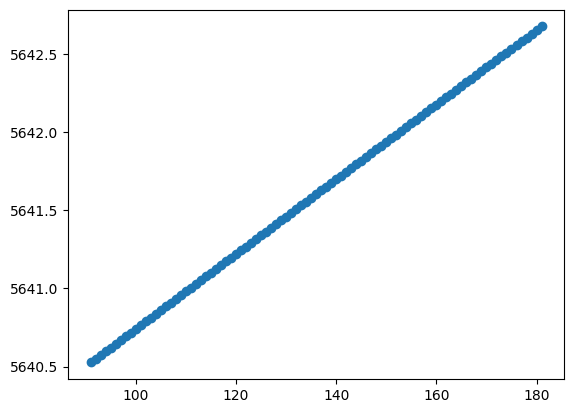

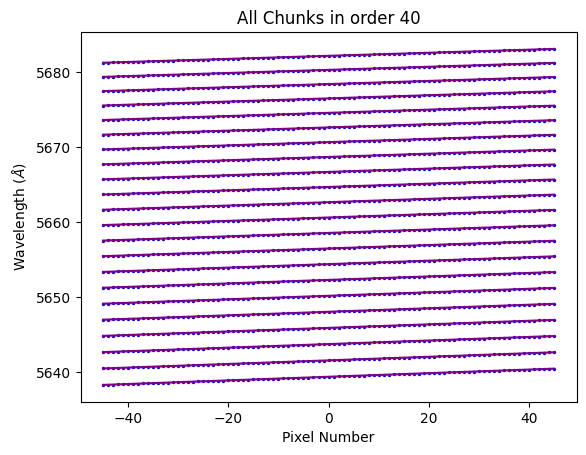

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [4]:
pyodine_create_templates.create_template(utilities, Pars, ostar_files, temp_files, 
                                         temp_outname, plot_dir=plot_dir, res_files=res_files, 
                                         obs_sum_outname=obs_sum_outname, error_log=error_file, 
                                         info_log=info_file)

In [5]:
fit_results_1 = pyodine.fitters.results_io.load_results(res_files[1], filetype='dill')

# Also construct the original chunks array of the O/B-star observations
chunks = pyodine.components.ChunkArray()
for r in fit_results_1:
    chunks.append(r.chunk)

In [6]:
print('Number of chunks/fit results:', len(fit_results_1))
print('\nObject structure of each fit result:')
print(fit_results_1[0].__dict__)


Number of chunks/fit results: 44

Object structure of each fit result:
{'chunk': <pyodine.components.Chunk object at 0x7f1bcc62aed0>, 'model': <pyodine.models.spectrum.SimpleModel object at 0x7f1a5c3863c0>, 'lmfit_result': <lmfit.minimizer.MinimizerResult object at 0x7f1a58ac05c0>, 'chunk_ind': 0}


In [8]:

chunks, fit_results_0 = pyodine.fitters.results_io.restore_results_object(
    utilities, res_files[0])
chunk_ind = 25


APF IN USE
APF IN USE
APF IN USE
APF IN USE
APF IN USE
APF IN USE
Total number of created chunks: 44 (in result file: 44)
Number of created chunks in order 0: 22


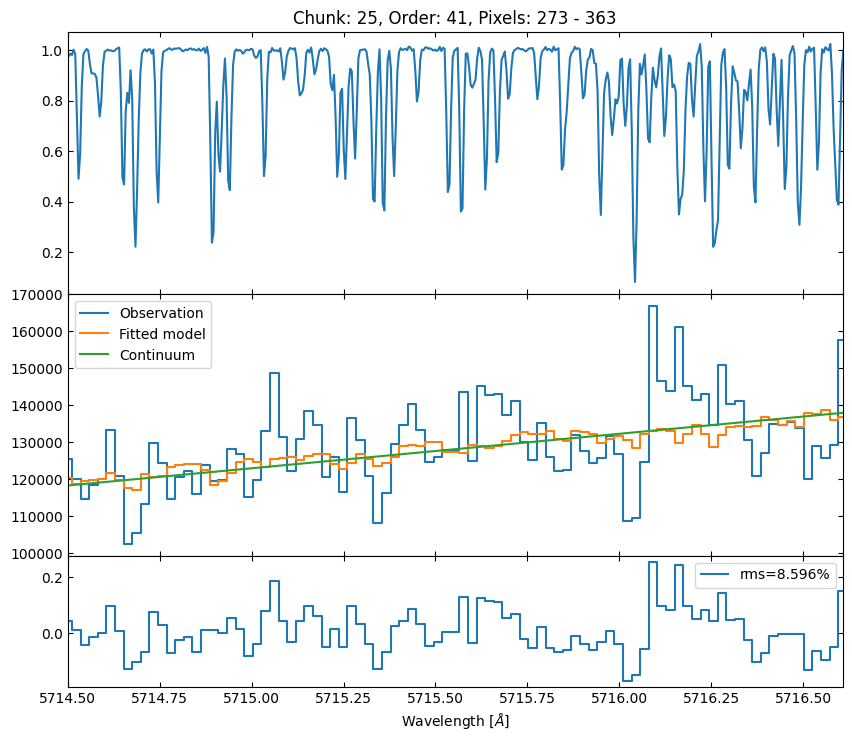

In [9]:

pyodine.plot_lib.plot_chunkmodel(fit_results_0, chunks, chunk_ind, template=False, 
                                 show_plot=True)

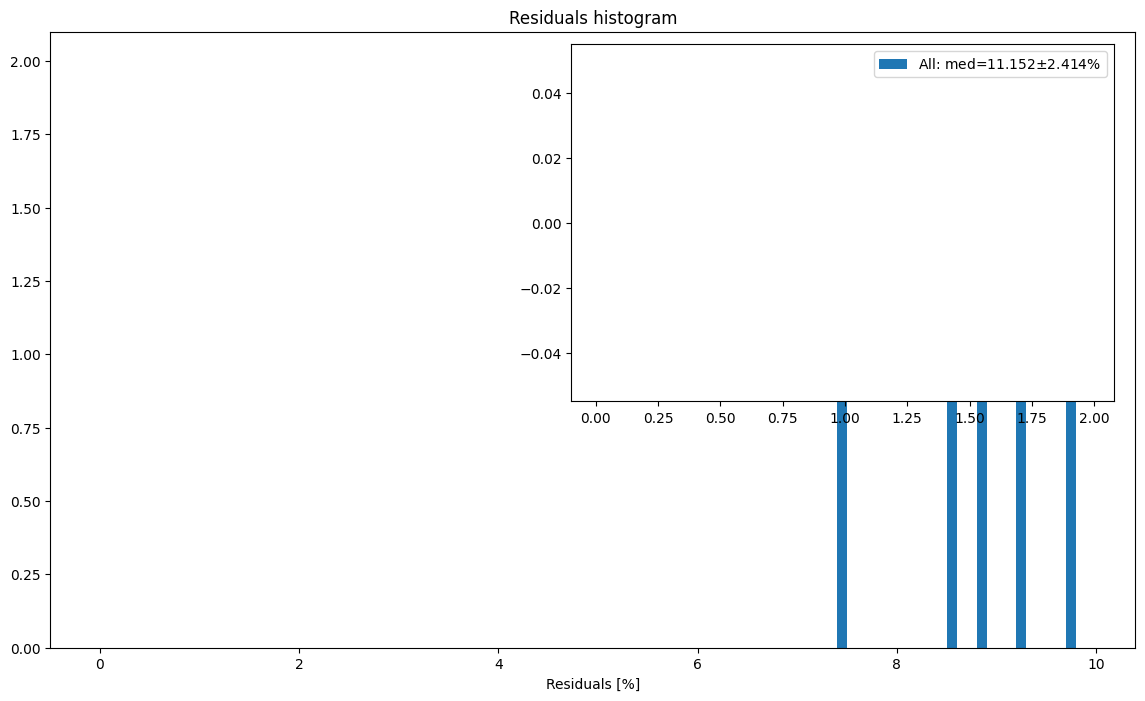

In [9]:

residuals = pyodine.plot_lib.plot_residual_hist(fit_results_0, title='Residuals histogram', 
                                                show_plot=True)

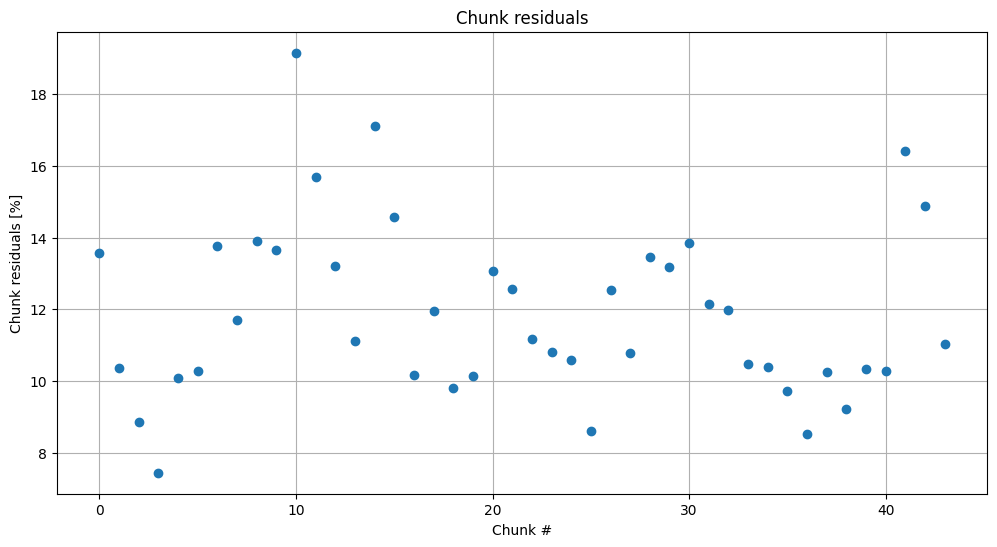

In [10]:
pyodine.plot_lib.plot_chunk_scatter(scatter=residuals, ylabel='Chunk residuals [%]', 
                                    title='Chunk residuals', show_plot=True)

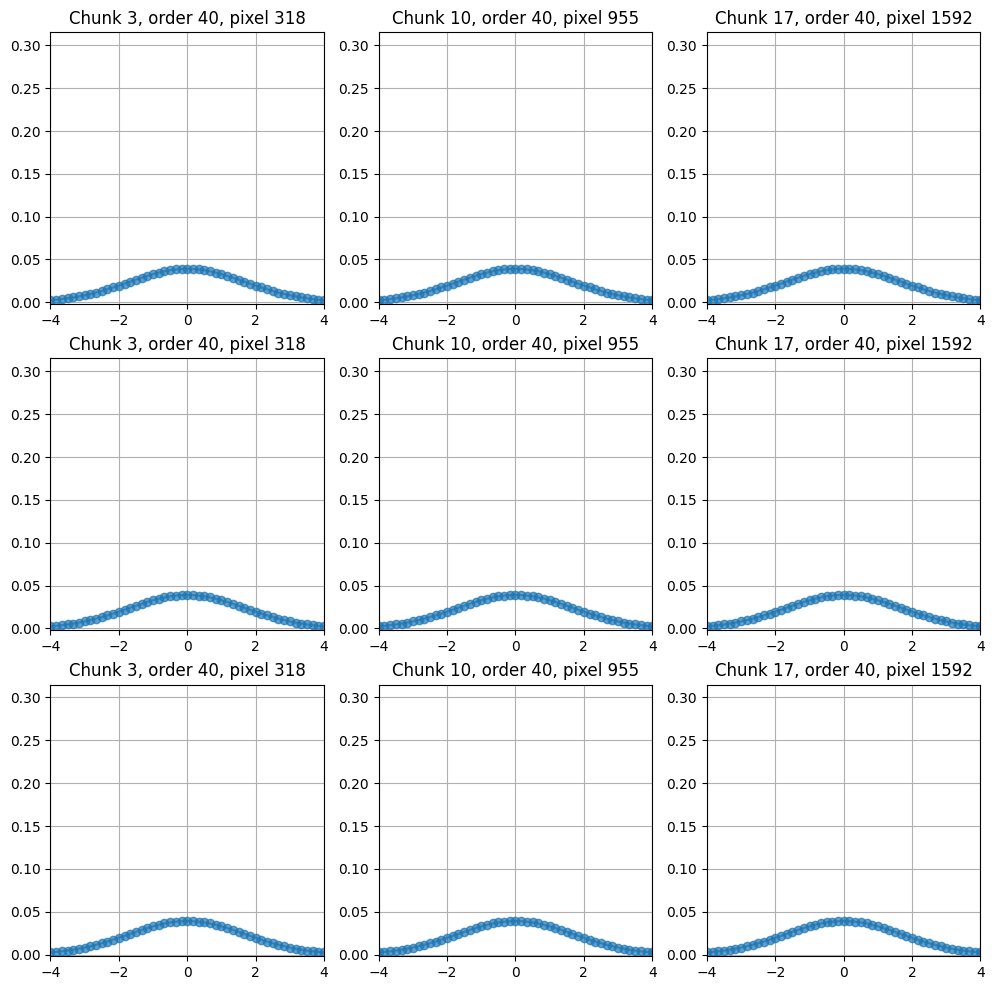

In [11]:
# The LSF model, oversampling and convolution width used
lsf_model      = fit_results_0[0].model.lsf_model
osample_factor = fit_results_0[0].model.osample_factor
conv_width     = fit_results_0[0].model.conv_width

# Generate the pixel vector to evaluate the LSF over
lsf_x = lsf_model.generate_x(osample_factor=osample_factor, conv_width=conv_width)

# Now loop over all chunks, evaluate the LSFs and append them to a list
lsfs = []
for i in range(len(fit_results_0)):
    lsf_pars = fit_results_0[i].params.filter('lsf')
    lsfs.append(lsf_model.eval(lsf_x, lsf_pars))

# Finally plot a grid of 3x3 LSFs
pyodine.plot_lib.plot_lsfs_grid(lsfs, chunks, x_lsf=lsf_x, x_nr=3, y_nr=3, 
                                alpha=0.7, xlim=(-4,4), show_plot=True)

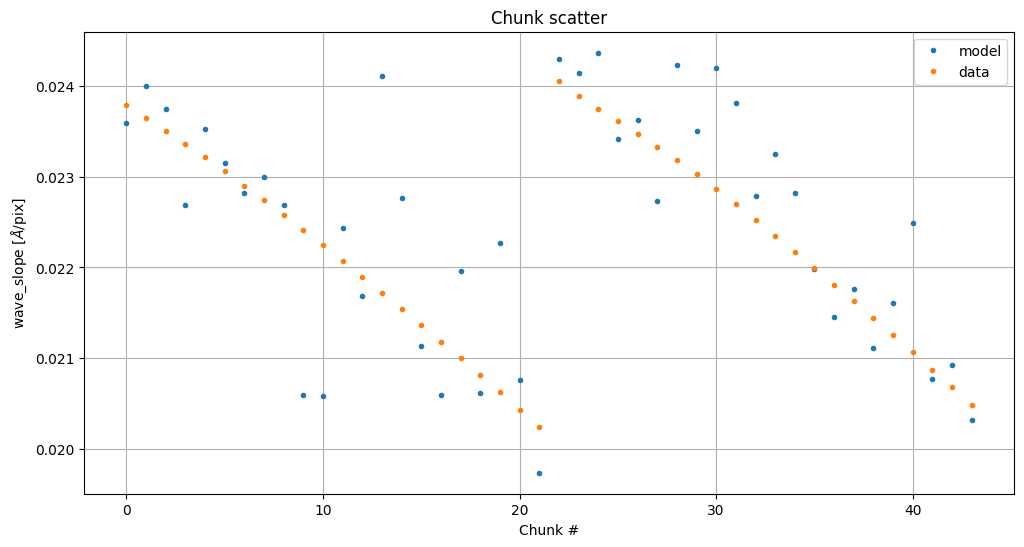

In [12]:
# The best-fit wavelength slopes for all chunks
wave_slopes_model = [r.params['wave_slope'] for r in fit_results_0]
# The estimated dispersion for all chunks (from the original spectrum)
wave_slopes_data = [(ch.wave[-1]-ch.wave[0])/len(ch) for ch in chunks]

pyodine.plot_lib.plot_chunk_scatter(scatter=[wave_slopes_model,wave_slopes_data], 
                                    scatter_fmt='.', scatter_label=['model', 'data'], 
                                    ylabel=r'wave_slope [$\AA$/pix]', show_plot=True)

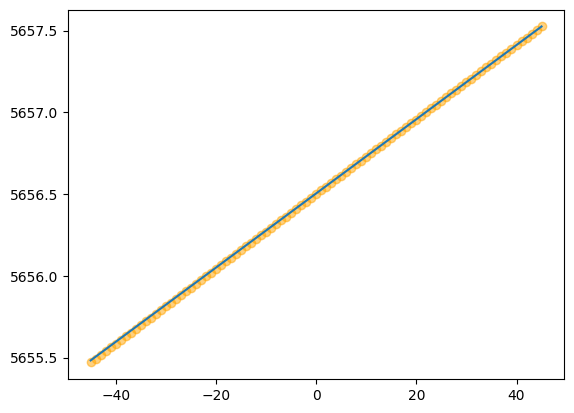

In [13]:
plt.plot(chunks[8].pix, chunks[8].pix*fit_results_0[8].params['wave_slope']+fit_results_0[8].params['wave_intercept'])
plt.scatter(chunks[8].pix,chunks[8].wave,alpha=.5,color= 'orange')